# Image Segmentation

**Absolute beginner → confident image segmentation**

Master SIP · École Centrale de Nantes · Denos Kume

This notebook builds segmentation progressively:

**pixels → labels → binary masks → thresholding → Otsu → adaptive thresholding → morphology → connected components → contours → region measurements → watershed → evaluation metrics → end-to-end segmentation pipeline**

## Problem Statement

Image segmentation assigns pixels to meaningful regions or object classes.

Unlike image classification, which predicts one label for an entire image, segmentation answers:

> Which pixels belong to the object, and which belong to the background?

In this lab we focus on classical image segmentation because it teaches the concepts that also appear in modern computer-vision systems:

- masks;
- foreground/background separation;
- connected regions;
- object boundaries;
- morphological cleanup;
- region measurements;
- segmentation metrics.

## Learning Objectives

By the end of the notebook, you should be able to:

1. Explain what image segmentation is.
2. Distinguish classification, detection, and segmentation.
3. Build binary masks from grayscale images.
4. Apply global thresholding.
5. Explain and implement Otsu thresholding.
6. Use adaptive/local thresholding for non-uniform illumination.
7. Understand erosion, dilation, opening, and closing.
8. Select useful structuring elements.
9. Remove small objects and fill holes.
10. Label connected components.
11. Extract contours and region properties.
12. Understand distance transforms.
13. Apply watershed segmentation.
14. Detect over-segmentation and under-segmentation.
15. Compute Dice, IoU, precision, recall, and pixel accuracy.
16. Build a complete segmentation pipeline.
17. Diagnose common segmentation errors.
18. Explain the main classical segmentation concepts in an exam or interview.

## 0. Setup

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from scipy import ndimage

import cv2

np.set_printoptions(precision=3, suppress=True)

print("NumPy :", np.__version__)
print("OpenCV:", cv2.__version__)
print("Setup : PASS")

NumPy : 2.5.3
OpenCV: 5.0.0
Setup : PASS


### 0.1 Locate the lab automatically

VS Code may execute the notebook from different working directories.

Instead of hard-coding a working directory, we search for the expected `data/hand.png` file.

In [2]:
def find_lab_root():
    cwd = Path.cwd().resolve()

    for candidate in [cwd, *cwd.parents]:
        if (candidate / "data" / "hand.png").exists():
            return candidate

        nested = (
            candidate
            / "Lab_Works"
            / "Image_Processing"
            / "Image_Segmentation"
        )

        if (nested / "data" / "hand.png").exists():
            return nested

    raise FileNotFoundError(
        "Could not locate Image_Segmentation."
    )


LAB_ROOT = find_lab_root()
DATA_DIR = LAB_ROOT / "data"
OUTPUT_DIR = LAB_ROOT / "outputs" / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Lab root:", LAB_ROOT)
print("Data dir:", DATA_DIR)
print("Output  :", OUTPUT_DIR)

Lab root: /home/denos/Master_SIP_EC-Nantes/Lab_Works/Image_Processing/Image_Segmentation
Data dir: /home/denos/Master_SIP_EC-Nantes/Lab_Works/Image_Processing/Image_Segmentation/data
Output  : /home/denos/Master_SIP_EC-Nantes/Lab_Works/Image_Processing/Image_Segmentation/outputs/figures


### 0.2 Reusable helpers

In [3]:
def load_gray(path):
    return np.asarray(
        Image.open(path).convert("L"),
        dtype=np.uint8
    )


def load_rgb(path):
    return np.asarray(
        Image.open(path).convert("RGB"),
        dtype=np.uint8
    )


def show_gray(ax, image, title):
    ax.imshow(image, cmap="gray")
    ax.set_title(title)
    ax.axis("off")


def show_rgb(ax, image, title):
    ax.imshow(image)
    ax.set_title(title)
    ax.axis("off")


def save_figure(fig, filename):
    path = OUTPUT_DIR / filename
    fig.savefig(path, dpi=160, bbox_inches="tight")
    print("Saved:", path.name)


def to_uint8_mask(mask):
    return (
        np.asarray(mask).astype(bool) * 255
    ).astype(np.uint8)


def overlay_mask(image_rgb, mask, alpha=0.35):
    output = image_rgb.astype(np.float32).copy()
    mask_bool = np.asarray(mask).astype(bool)

    red = np.zeros_like(output)
    red[..., 0] = 255

    output[mask_bool] = (
        (1 - alpha) * output[mask_bool]
        + alpha * red[mask_bool]
    )

    return np.clip(output, 0, 255).astype(np.uint8)

## 1. What Is Image Segmentation?

Segmentation assigns a label to each pixel.

For binary segmentation:

$$
M(x,y)=
\begin{cases}
1,&\text{foreground}\\
0,&\text{background}
\end{cases}
$$

The result is a **mask**.

A segmentation mask is not merely a visualization. It is a data structure that can be used to:

- measure object area;
- isolate an object;
- compute shape descriptors;
- count instances;
- guide later computer-vision steps.

### Classification vs Detection vs Segmentation

| Task | Output |
|---|---|
| Classification | one label for the image |
| Object detection | bounding boxes + labels |
| Semantic segmentation | class label per pixel |
| Instance segmentation | separate mask per object instance |

This lab focuses mainly on **binary and classical region segmentation**.

## 2. Load the Lab Images

Saved: 01_input_images.png


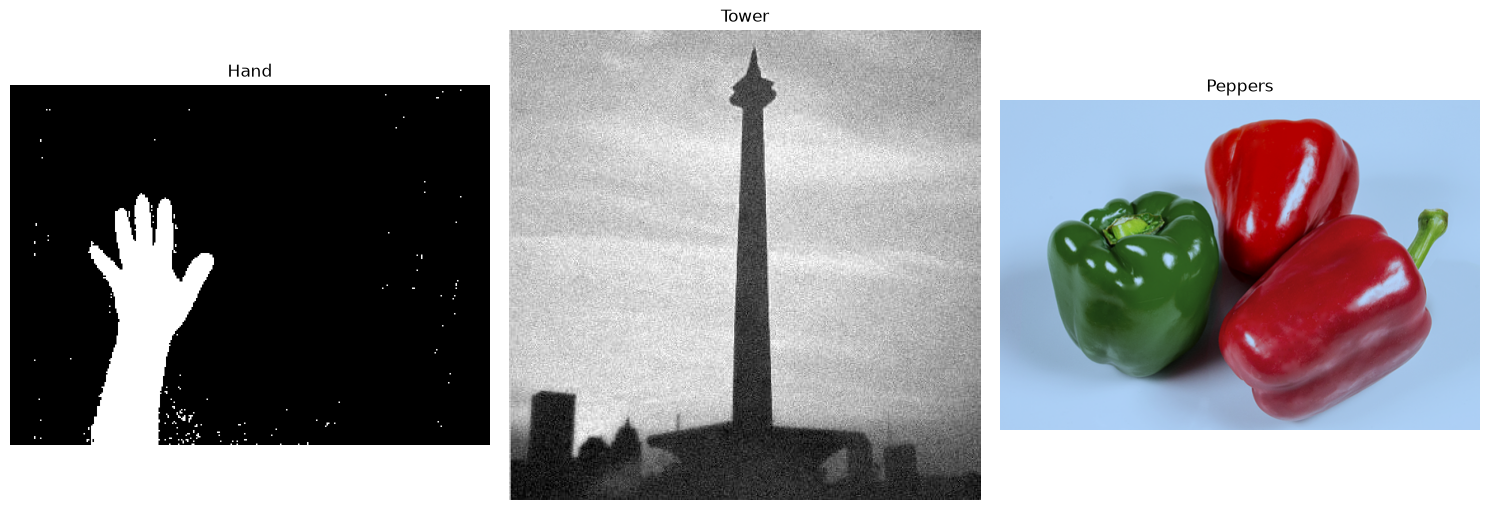

hand shape   : (480, 640)
tower shape  : (370, 371, 3)
peppers shape: (417, 606, 3)


In [4]:
hand = load_gray(
    DATA_DIR / "hand.png"
)

tower_rgb = load_rgb(
    DATA_DIR / "tower.jpg"
)

peppers_rgb = load_rgb(
    DATA_DIR / "peppers.png"
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

show_gray(
    axes[0],
    hand,
    "Hand"
)

show_rgb(
    axes[1],
    tower_rgb,
    "Tower"
)

show_rgb(
    axes[2],
    peppers_rgb,
    "Peppers"
)

fig.tight_layout()
save_figure(
    fig,
    "01_input_images.png"
)
plt.show()

print("hand shape   :", hand.shape)
print("tower shape  :", tower_rgb.shape)
print("peppers shape:", peppers_rgb.shape)

## 3. Histograms and Why Thresholding Can Work

A grayscale histogram counts how many pixels have each intensity.

If foreground and background occupy different intensity ranges, a threshold can separate them.

Binary thresholding:

$$
M(x,y)=
\begin{cases}
1,&I(x,y)>T\\
0,&I(x,y)\le T
\end{cases}
$$

Whether the foreground is above or below the threshold depends on the image.

Saved: 02_hand_histogram.png


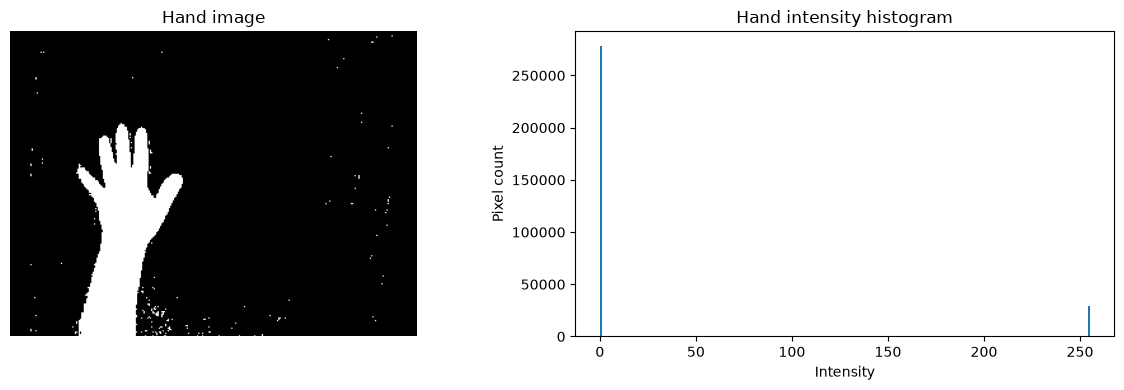

In [5]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)

show_gray(
    axes[0],
    hand,
    "Hand image"
)

axes[1].hist(
    hand.ravel(),
    bins=256,
    range=(0, 255)
)
axes[1].set_title(
    "Hand intensity histogram"
)
axes[1].set_xlabel(
    "Intensity"
)
axes[1].set_ylabel(
    "Pixel count"
)

fig.tight_layout()
save_figure(
    fig,
    "02_hand_histogram.png"
)
plt.show()

### Interpretation

Thresholding works best when object and background have distinguishable intensity distributions.

It becomes difficult when:

- object and background intensities overlap;
- illumination is non-uniform;
- shadows are present;
- texture dominates intensity;
- noise creates isolated false pixels.

That is why segmentation is usually a **pipeline**, not a single threshold operation.

## 4. Manual Global Thresholding

Let's start with the simplest segmentation.

Saved: 03_manual_threshold.png


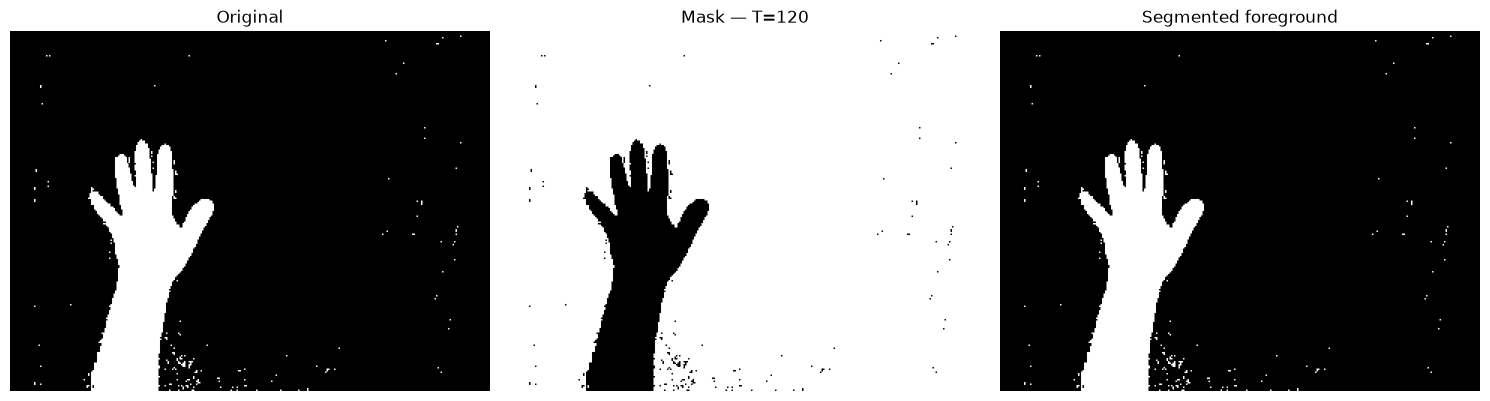

In [6]:
manual_threshold = 120

mask_manual = hand < manual_threshold

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

show_gray(
    axes[0],
    hand,
    "Original"
)

show_gray(
    axes[1],
    mask_manual,
    f"Mask — T={manual_threshold}"
)

masked_hand = np.where(
    mask_manual,
    hand,
    255
)

show_gray(
    axes[2],
    masked_hand,
    "Segmented foreground"
)

fig.tight_layout()
save_figure(
    fig,
    "03_manual_threshold.png"
)
plt.show()

### What the Threshold Really Does

A threshold does not "understand" a hand.

It only separates pixels according to intensity.

So thresholding is useful when the image acquisition conditions create a meaningful intensity distinction.

## 5. Threshold Sensitivity

A good segmentation method should not be understood from only one threshold.

Let's vary the threshold and observe the effect.

Saved: 04_threshold_sensitivity.png


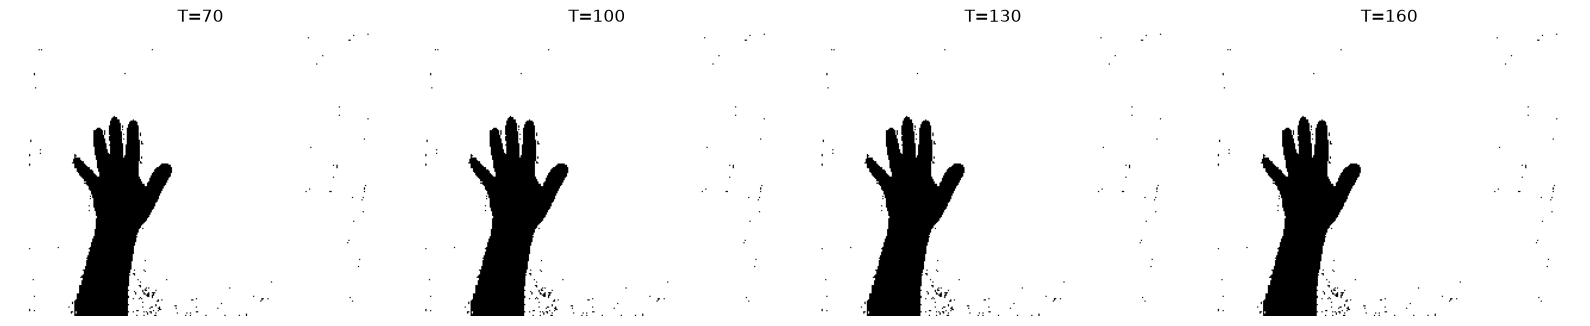

In [7]:
thresholds = [
    70,
    100,
    130,
    160
]

fig, axes = plt.subplots(
    1,
    len(thresholds),
    figsize=(16, 4)
)

for ax, threshold in zip(
    axes,
    thresholds
):
    mask = hand < threshold

    show_gray(
        ax,
        mask,
        f"T={threshold}"
    )

fig.tight_layout()
save_figure(
    fig,
    "04_threshold_sensitivity.png"
)
plt.show()

### Key Lesson

- threshold too low → foreground may be missed;
- threshold too high → background may leak into the mask.

A manually selected threshold can work well in controlled conditions, but it may not generalize.

## 6. Otsu Thresholding

Otsu automatically chooses a global threshold by maximizing separation between two intensity classes.

Equivalent interpretation:

> choose the threshold that minimizes within-class variance.

For candidate threshold $T$:

- pixels below $T$ form one class;
- pixels above $T$ form another class.

Otsu works especially well when the histogram is approximately bimodal.

Otsu threshold: 0.0
Saved: 05_otsu_threshold.png


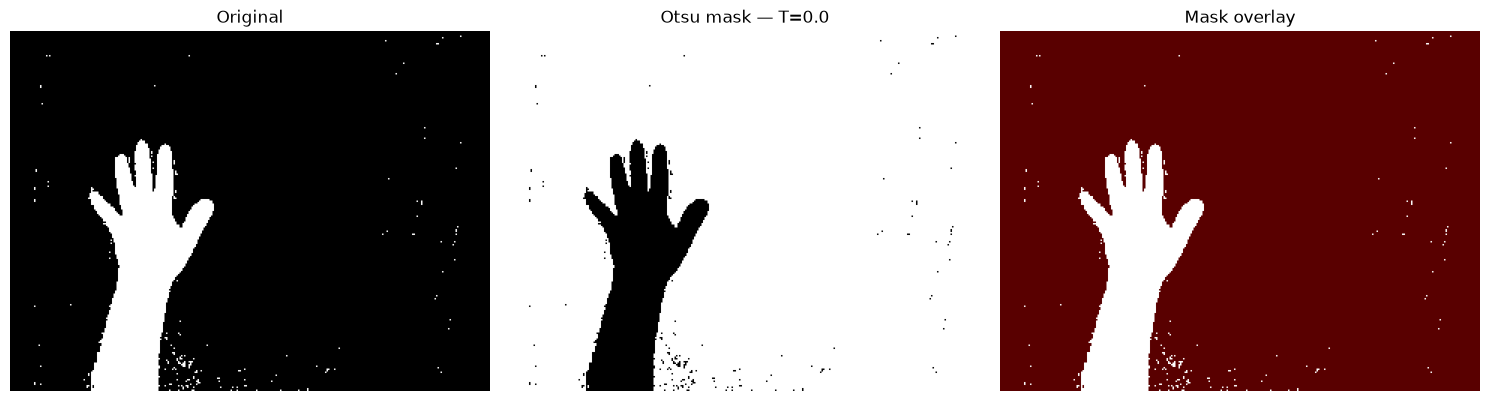

In [8]:
otsu_threshold, mask_otsu_cv = cv2.threshold(
    hand,
    0,
    255,
    cv2.THRESH_BINARY_INV
    + cv2.THRESH_OTSU
)

mask_otsu = (
    mask_otsu_cv > 0
)

print(
    "Otsu threshold:",
    otsu_threshold
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

show_gray(
    axes[0],
    hand,
    "Original"
)

show_gray(
    axes[1],
    mask_otsu,
    f"Otsu mask — T={otsu_threshold:.1f}"
)

overlay = overlay_mask(
    np.stack([hand] * 3, axis=-1),
    mask_otsu
)

show_rgb(
    axes[2],
    overlay,
    "Mask overlay"
)

fig.tight_layout()
save_figure(
    fig,
    "05_otsu_threshold.png"
)
plt.show()

### When Otsu Works Well

- approximately bimodal histogram;
- relatively uniform illumination;
- clear foreground/background distinction.

### When Otsu Can Fail

- uneven illumination;
- multiple classes;
- overlapping intensity distributions;
- weak contrast;
- very small foreground proportion.

## 7. Gaussian Smoothing Before Thresholding

Noise can make a binary mask unstable.

A common strategy is:

1. smooth image;
2. threshold smoothed image.

This reduces isolated intensity fluctuations.

Saved: 06_smoothing_before_otsu.png


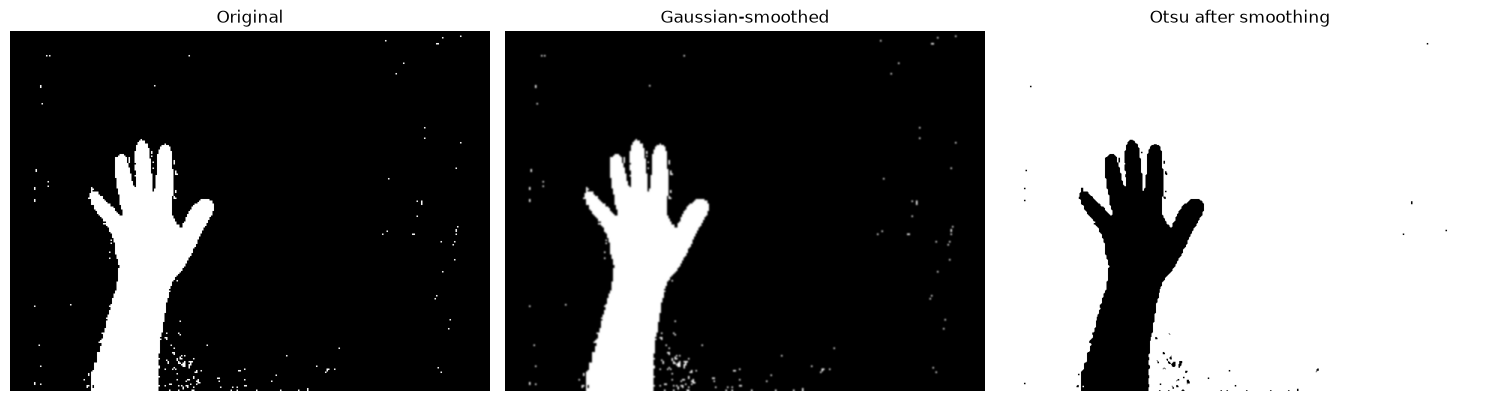

In [9]:
hand_blurred = cv2.GaussianBlur(
    hand,
    (5, 5),
    0
)

blur_otsu_threshold, blur_otsu_cv = cv2.threshold(
    hand_blurred,
    0,
    255,
    cv2.THRESH_BINARY_INV
    + cv2.THRESH_OTSU
)

blur_otsu = (
    blur_otsu_cv > 0
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

show_gray(
    axes[0],
    hand,
    "Original"
)

show_gray(
    axes[1],
    hand_blurred,
    "Gaussian-smoothed"
)

show_gray(
    axes[2],
    blur_otsu,
    "Otsu after smoothing"
)

fig.tight_layout()
save_figure(
    fig,
    "06_smoothing_before_otsu.png"
)
plt.show()

## 8. Adaptive Thresholding

A single global threshold assumes the same illumination condition everywhere.

Adaptive thresholding computes a local threshold for each neighborhood.

This is useful when illumination changes across the image.

Common forms:

- adaptive mean;
- adaptive Gaussian.

Saved: 07_adaptive_thresholding.png


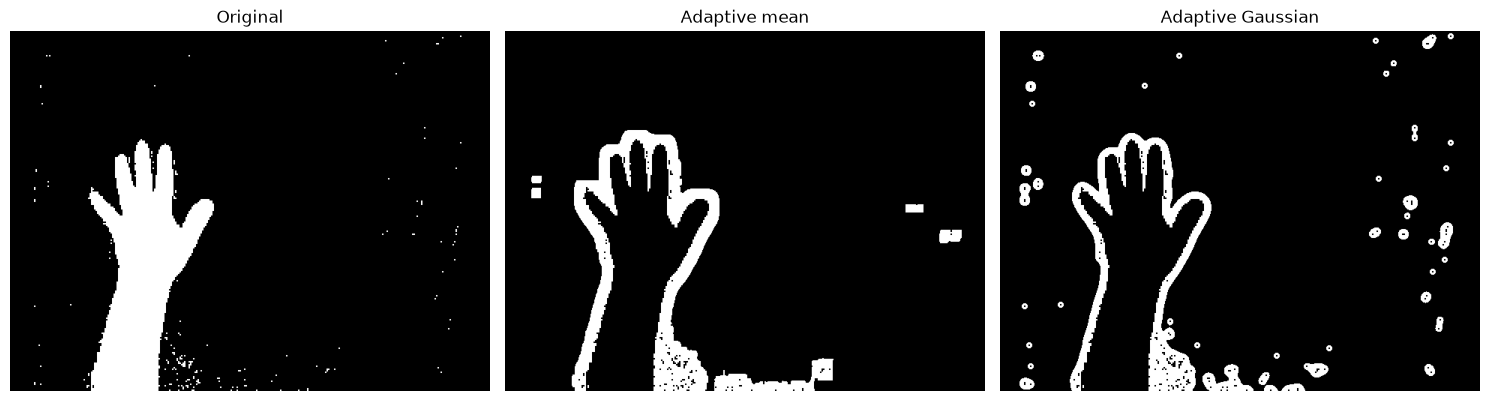

In [10]:
adaptive_mean = cv2.adaptiveThreshold(
    hand,
    255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY_INV,
    31,
    5
)

adaptive_gaussian = cv2.adaptiveThreshold(
    hand,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    31,
    5
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

show_gray(
    axes[0],
    hand,
    "Original"
)

show_gray(
    axes[1],
    adaptive_mean,
    "Adaptive mean"
)

show_gray(
    axes[2],
    adaptive_gaussian,
    "Adaptive Gaussian"
)

fig.tight_layout()
save_figure(
    fig,
    "07_adaptive_thresholding.png"
)
plt.show()

### Adaptive Parameters

`blockSize` controls the local neighborhood.

`C` shifts the local threshold.

Very small neighborhoods can react strongly to noise.  
Very large neighborhoods approach global behavior.

## 9. Morphological Processing

Thresholding frequently creates masks with:

- small false regions;
- small holes;
- rough boundaries;
- disconnected object fragments.

Morphological operations modify binary shapes using a **structuring element**.

The two fundamental operations are:

- erosion;
- dilation.

## 10. Structuring Elements

A structuring element defines the neighborhood used by morphology.

Typical shapes:

- rectangle;
- ellipse/disk;
- cross.

Its size determines how aggressively the mask is changed.

Saved: 08_structuring_elements.png


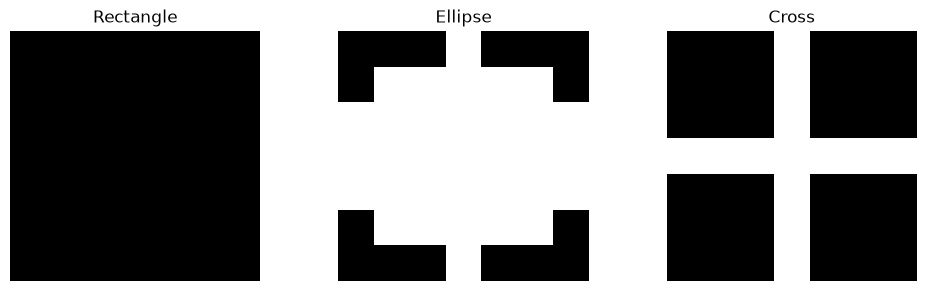

In [11]:
kernel_rect = cv2.getStructuringElement(
    cv2.MORPH_RECT,
    (7, 7)
)

kernel_ellipse = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (7, 7)
)

kernel_cross = cv2.getStructuringElement(
    cv2.MORPH_CROSS,
    (7, 7)
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(10, 3)
)

show_gray(
    axes[0],
    kernel_rect,
    "Rectangle"
)

show_gray(
    axes[1],
    kernel_ellipse,
    "Ellipse"
)

show_gray(
    axes[2],
    kernel_cross,
    "Cross"
)

fig.tight_layout()
save_figure(
    fig,
    "08_structuring_elements.png"
)
plt.show()

## 11. Erosion and Dilation

### Erosion

Erosion shrinks foreground regions.

It can:

- remove small bright/foreground noise;
- break thin bridges;
- separate objects.

### Dilation

Dilation expands foreground regions.

It can:

- fill small gaps;
- connect nearby fragments;
- enlarge objects.

Saved: 09_erosion_dilation.png


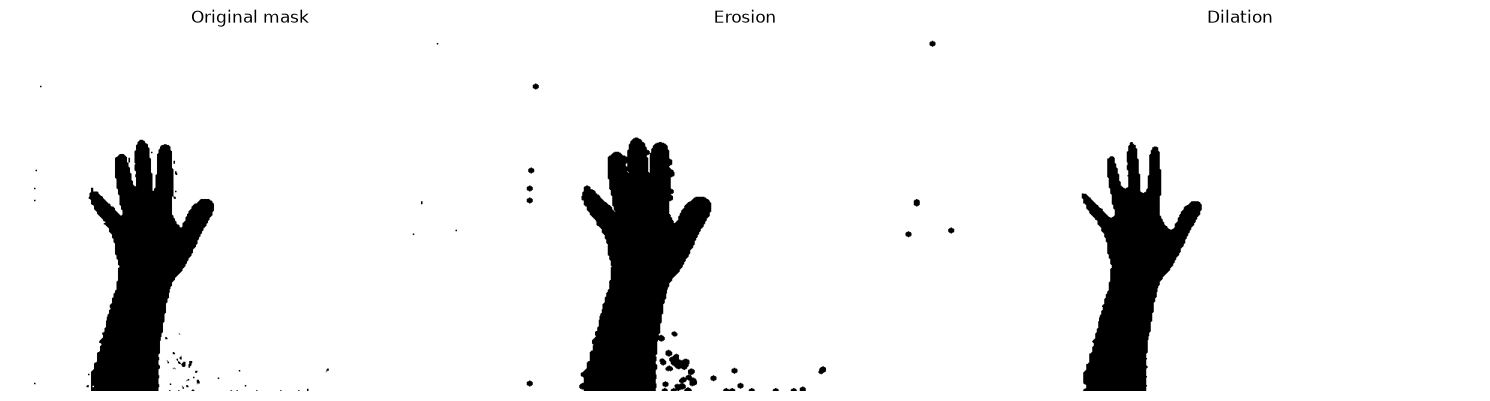

In [12]:
mask_uint8 = to_uint8_mask(
    blur_otsu
)

kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (7, 7)
)

eroded = cv2.erode(
    mask_uint8,
    kernel,
    iterations=1
)

dilated = cv2.dilate(
    mask_uint8,
    kernel,
    iterations=1
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

show_gray(
    axes[0],
    mask_uint8,
    "Original mask"
)

show_gray(
    axes[1],
    eroded,
    "Erosion"
)

show_gray(
    axes[2],
    dilated,
    "Dilation"
)

fig.tight_layout()
save_figure(
    fig,
    "09_erosion_dilation.png"
)
plt.show()

## 12. Opening and Closing

### Opening

Opening = erosion followed by dilation:

$$
A\circ B
=
(A\ominus B)\oplus B
$$

Useful for removing small foreground objects/noise.

### Closing

Closing = dilation followed by erosion:

$$
A\bullet B
=
(A\oplus B)\ominus B
$$

Useful for filling small holes or gaps.

Saved: 10_opening_closing.png


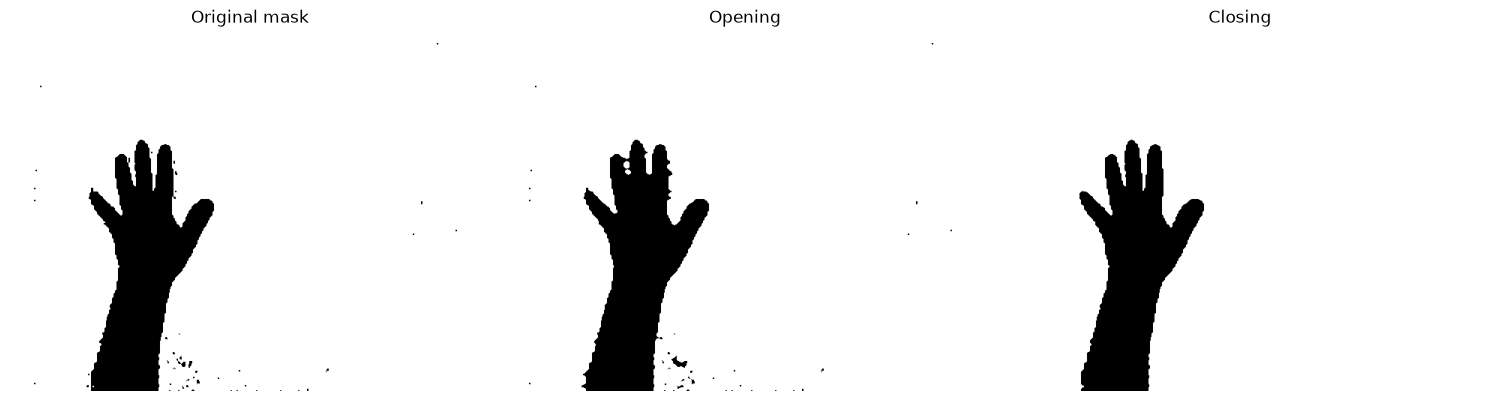

In [13]:
opened = cv2.morphologyEx(
    mask_uint8,
    cv2.MORPH_OPEN,
    kernel
)

closed = cv2.morphologyEx(
    mask_uint8,
    cv2.MORPH_CLOSE,
    kernel
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

show_gray(
    axes[0],
    mask_uint8,
    "Original mask"
)

show_gray(
    axes[1],
    opened,
    "Opening"
)

show_gray(
    axes[2],
    closed,
    "Closing"
)

fig.tight_layout()
save_figure(
    fig,
    "10_opening_closing.png"
)
plt.show()

## 13. Morphological Gradient

The morphological gradient approximates object boundaries:

$$
G
=
\text{dilation}
-
\text{erosion}
$$

Saved: 11_morphological_gradient.png


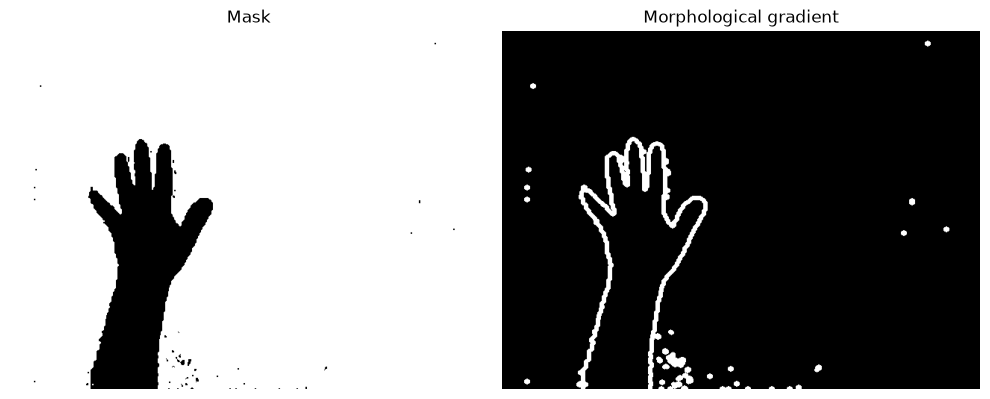

In [14]:
morph_gradient = cv2.morphologyEx(
    mask_uint8,
    cv2.MORPH_GRADIENT,
    kernel
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 5)
)

show_gray(
    axes[0],
    mask_uint8,
    "Mask"
)

show_gray(
    axes[1],
    morph_gradient,
    "Morphological gradient"
)

fig.tight_layout()
save_figure(
    fig,
    "11_morphological_gradient.png"
)
plt.show()

## 14. Hole Filling

A segmented object may contain unwanted internal holes.

SciPy provides a simple binary hole-filling operation.

Saved: 12_hole_filling.png


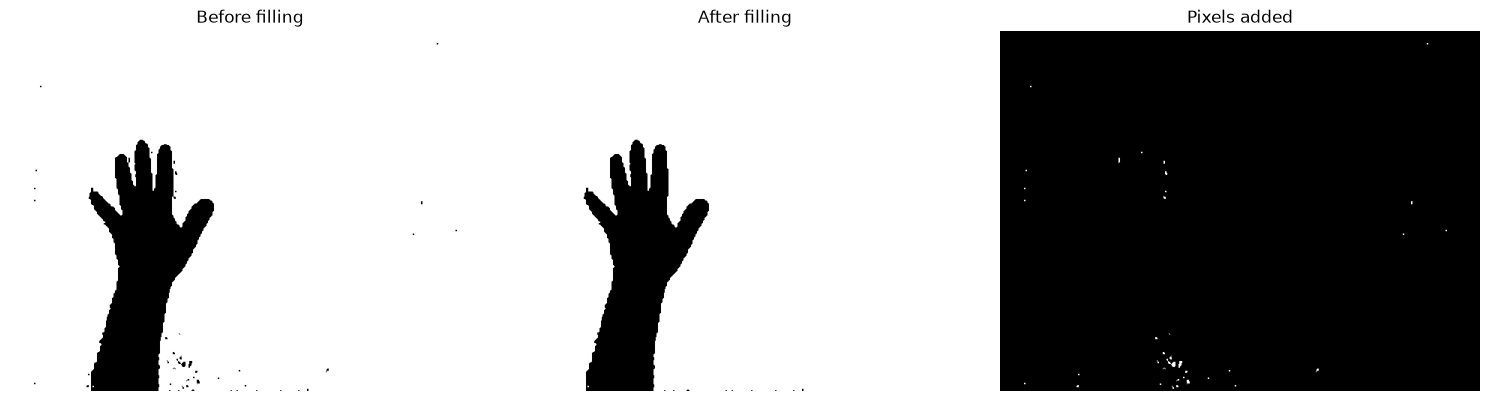

In [15]:
mask_with_holes = blur_otsu.astype(bool)

filled = ndimage.binary_fill_holes(
    mask_with_holes
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

show_gray(
    axes[0],
    mask_with_holes,
    "Before filling"
)

show_gray(
    axes[1],
    filled,
    "After filling"
)

show_gray(
    axes[2],
    filled.astype(int)
    - mask_with_holes.astype(int),
    "Pixels added"
)

fig.tight_layout()
save_figure(
    fig,
    "12_hole_filling.png"
)
plt.show()

## 15. Connected Components

Connected-component labeling assigns a unique integer label to each connected foreground region.

For binary image $M$:

- label 0 usually represents background;
- labels 1, 2, 3, ... represent components.

This enables:

- object counting;
- area filtering;
- centroid computation;
- bounding-box extraction.

Number of foreground components: 2
Foreground areas: [278980      4]
Saved: 13_connected_components.png


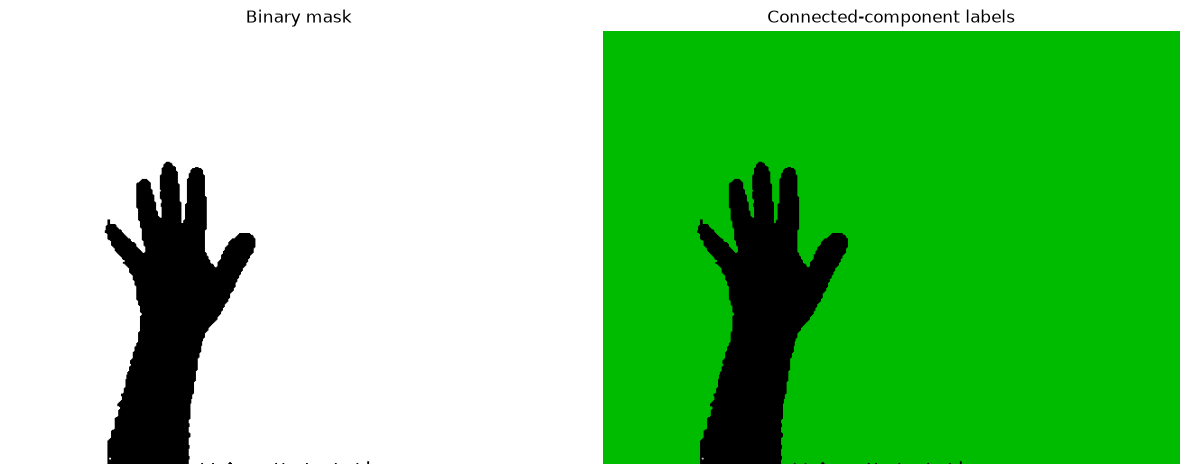

In [16]:
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    to_uint8_mask(filled),
    connectivity=8
)

print(
    "Number of foreground components:",
    num_labels - 1
)

component_areas = stats[
    1:,
    cv2.CC_STAT_AREA
]

print(
    "Foreground areas:",
    component_areas
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

show_gray(
    axes[0],
    filled,
    "Binary mask"
)

axes[1].imshow(
    labels,
    cmap="nipy_spectral"
)
axes[1].set_title(
    "Connected-component labels"
)
axes[1].axis("off")

fig.tight_layout()
save_figure(
    fig,
    "13_connected_components.png"
)
plt.show()

## 16. Remove Small Components

A common cleanup rule is:

> Keep only connected components whose area exceeds a minimum threshold.

This is often safer than blindly applying aggressive morphology.

Saved: 14_component_area_filtering.png


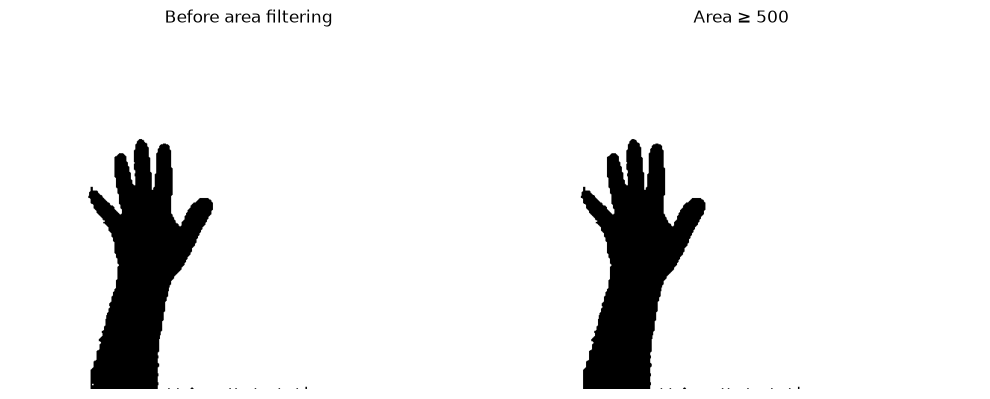

In [17]:
minimum_area = 500

clean_components = np.zeros_like(
    labels,
    dtype=bool
)

for label_id in range(
    1,
    num_labels
):
    area = stats[
        label_id,
        cv2.CC_STAT_AREA
    ]

    if area >= minimum_area:
        clean_components |= (
            labels == label_id
        )

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 5)
)

show_gray(
    axes[0],
    filled,
    "Before area filtering"
)

show_gray(
    axes[1],
    clean_components,
    f"Area ≥ {minimum_area}"
)

fig.tight_layout()
save_figure(
    fig,
    "14_component_area_filtering.png"
)
plt.show()

## 17. Contours

A contour is an ordered set of boundary points.

Contours are useful for:

- perimeter;
- bounding boxes;
- shape analysis;
- polygon approximation;
- visualization.

Saved: 15_contours.png


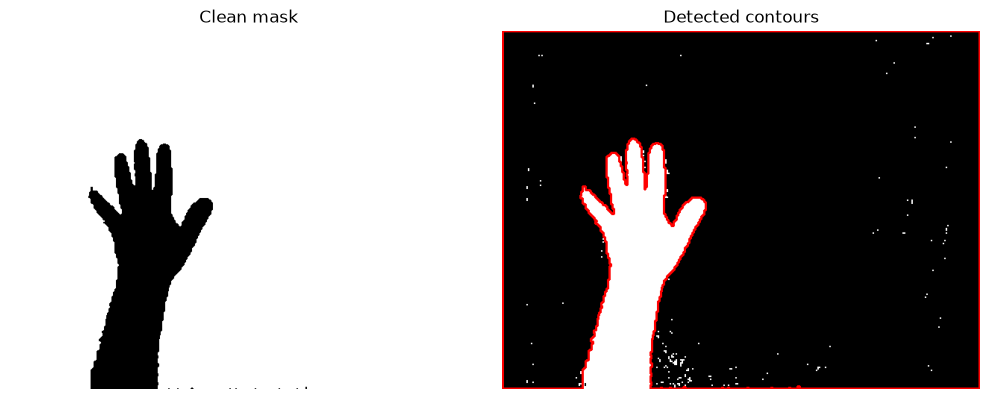

Number of external contours: 1


In [18]:
contours, hierarchy = cv2.findContours(
    to_uint8_mask(
        clean_components
    ),
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

hand_rgb = np.stack(
    [hand] * 3,
    axis=-1
)

contour_view = hand_rgb.copy()

cv2.drawContours(
    contour_view,
    contours,
    -1,
    (255, 0, 0),
    2
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 5)
)

show_gray(
    axes[0],
    clean_components,
    "Clean mask"
)

show_rgb(
    axes[1],
    contour_view,
    "Detected contours"
)

fig.tight_layout()
save_figure(
    fig,
    "15_contours.png"
)
plt.show()

print(
    "Number of external contours:",
    len(contours)
)

## 18. Region Properties

For each contour we can compute useful geometric measurements:

- area;
- perimeter;
- bounding rectangle;
- centroid;
- circularity;
- aspect ratio.

Circularity:

$$
C
=
\frac{4\pi A}{P^2}
$$

A perfect circle has circularity near 1.

In [19]:
region_rows = []

for index, contour in enumerate(
    contours,
    start=1
):
    area = cv2.contourArea(
        contour
    )

    perimeter = cv2.arcLength(
        contour,
        True
    )

    x, y, w, h = cv2.boundingRect(
        contour
    )

    moments = cv2.moments(
        contour
    )

    if moments["m00"] != 0:
        cx = moments["m10"] / moments["m00"]
        cy = moments["m01"] / moments["m00"]
    else:
        cx = np.nan
        cy = np.nan

    circularity = (
        4 * np.pi * area
        / (perimeter ** 2)
        if perimeter > 0
        else np.nan
    )

    aspect_ratio = (
        w / h
        if h > 0
        else np.nan
    )

    region_rows.append(
        {
            "component": index,
            "area": area,
            "perimeter": perimeter,
            "cx": cx,
            "cy": cy,
            "width": w,
            "height": h,
            "aspect_ratio": aspect_ratio,
            "circularity": circularity,
        }
    )

for row in region_rows:
    print(row)

{'component': 1, 'area': 277361.0, 'perimeter': 3376.832603573799, 'cx': 334.2808067224063, 'cy': 231.55805851098987, 'width': 640, 'height': 480, 'aspect_ratio': 1.3333333333333333, 'circularity': 0.3056583003657481}


## 19. Color Segmentation

Grayscale thresholding ignores color information.

For color images, segmentation can be easier in color spaces such as:

- RGB;
- HSV;
- Lab.

HSV is useful because hue approximately separates color from brightness.

Saved: 16_hsv_channels.png


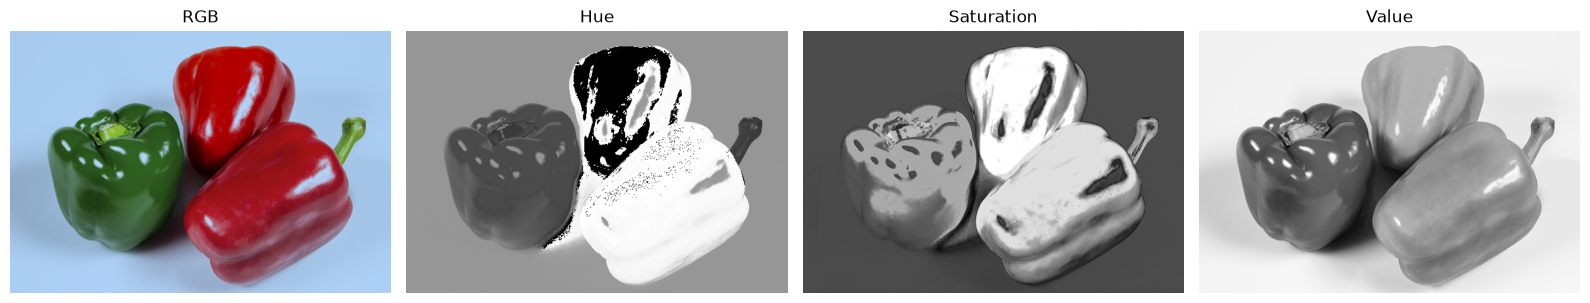

In [20]:
peppers_hsv = cv2.cvtColor(
    peppers_rgb,
    cv2.COLOR_RGB2HSV
)

hue = peppers_hsv[..., 0]
saturation = peppers_hsv[..., 1]
value = peppers_hsv[..., 2]

fig, axes = plt.subplots(
    1,
    4,
    figsize=(16, 4)
)

show_rgb(
    axes[0],
    peppers_rgb,
    "RGB"
)

show_gray(
    axes[1],
    hue,
    "Hue"
)

show_gray(
    axes[2],
    saturation,
    "Saturation"
)

show_gray(
    axes[3],
    value,
    "Value"
)

fig.tight_layout()
save_figure(
    fig,
    "16_hsv_channels.png"
)
plt.show()

### Example: segment a red-color range

OpenCV hue values are typically stored in the range 0–179.

Red wraps around the hue axis, so two intervals are often needed.

Saved: 17_color_segmentation.png


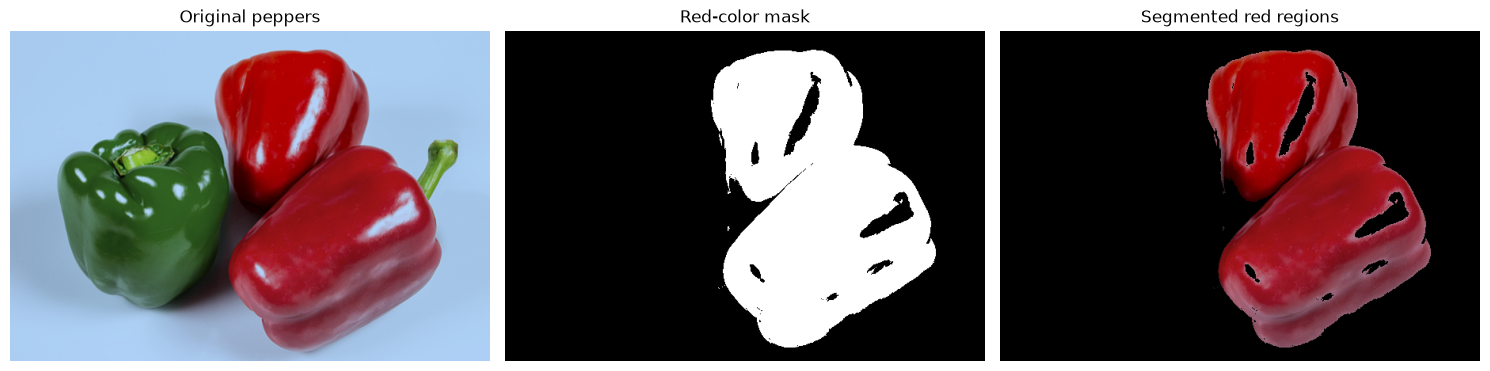

In [21]:
lower_red_1 = np.array(
    [0, 80, 50],
    dtype=np.uint8
)

upper_red_1 = np.array(
    [12, 255, 255],
    dtype=np.uint8
)

lower_red_2 = np.array(
    [165, 80, 50],
    dtype=np.uint8
)

upper_red_2 = np.array(
    [179, 255, 255],
    dtype=np.uint8
)

mask_red_1 = cv2.inRange(
    peppers_hsv,
    lower_red_1,
    upper_red_1
)

mask_red_2 = cv2.inRange(
    peppers_hsv,
    lower_red_2,
    upper_red_2
)

red_mask = (
    (mask_red_1 > 0)
    | (mask_red_2 > 0)
)

red_segment = peppers_rgb.copy()
red_segment[~red_mask] = 0

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

show_rgb(
    axes[0],
    peppers_rgb,
    "Original peppers"
)

show_gray(
    axes[1],
    red_mask,
    "Red-color mask"
)

show_rgb(
    axes[2],
    red_segment,
    "Segmented red regions"
)

fig.tight_layout()
save_figure(
    fig,
    "17_color_segmentation.png"
)
plt.show()

## 20. Edge-Based Segmentation Intuition

Segmentation can also begin from boundaries.

Typical steps:

1. detect edges;
2. connect broken boundaries;
3. close gaps;
4. fill enclosed regions.

Canny edge detection is a common starting point.

Saved: 18_edge_based_segmentation.png


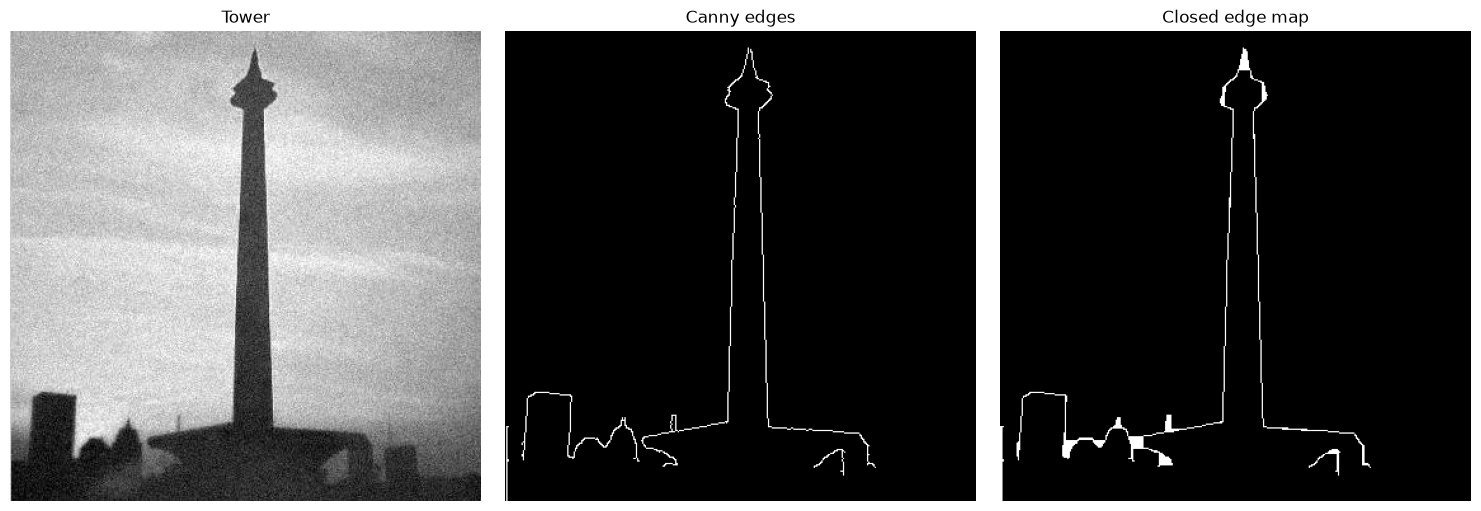

In [22]:
tower_gray = cv2.cvtColor(
    tower_rgb,
    cv2.COLOR_RGB2GRAY
)

tower_blur = cv2.GaussianBlur(
    tower_gray,
    (5, 5),
    0
)

tower_edges = cv2.Canny(
    tower_blur,
    80,
    160
)

edge_kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT,
    (5, 5)
)

tower_edges_closed = cv2.morphologyEx(
    tower_edges,
    cv2.MORPH_CLOSE,
    edge_kernel,
    iterations=2
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

show_rgb(
    axes[0],
    tower_rgb,
    "Tower"
)

show_gray(
    axes[1],
    tower_edges,
    "Canny edges"
)

show_gray(
    axes[2],
    tower_edges_closed,
    "Closed edge map"
)

fig.tight_layout()
save_figure(
    fig,
    "18_edge_based_segmentation.png"
)
plt.show()

## 21. Distance Transform

For a binary foreground region, the distance transform assigns each foreground pixel its distance to the nearest background pixel.

Inside an object:

- boundary pixels have small distance;
- central pixels have larger distance.

This is extremely useful for separating touching objects.

Saved: 19_distance_transform.png


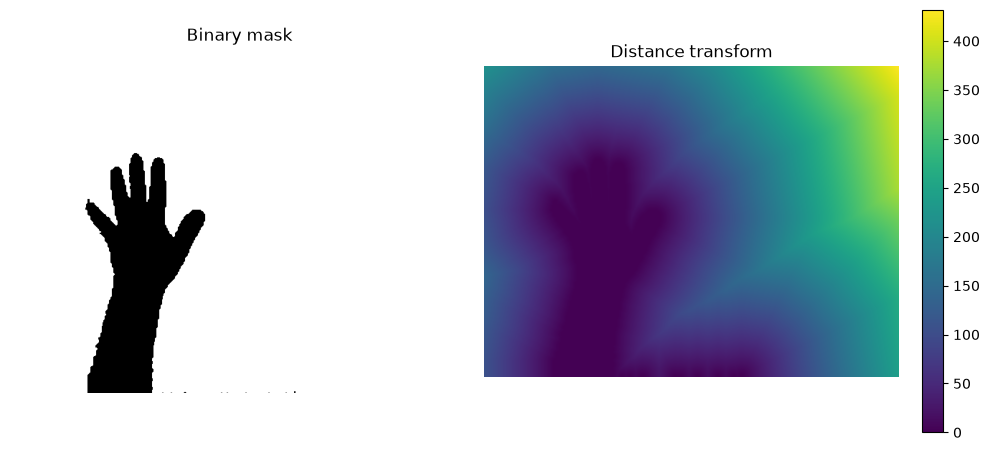

In [23]:
distance = cv2.distanceTransform(
    to_uint8_mask(clean_components),
    cv2.DIST_L2,
    5
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 5)
)

show_gray(
    axes[0],
    clean_components,
    "Binary mask"
)

im = axes[1].imshow(
    distance,
    cmap="viridis"
)

axes[1].set_title(
    "Distance transform"
)

axes[1].axis("off")

fig.colorbar(
    im,
    ax=axes[1],
    fraction=0.046
)

fig.tight_layout()
save_figure(
    fig,
    "19_distance_transform.png"
)
plt.show()

## 22. Watershed Segmentation

Watershed treats an image like a topographic surface.

Conceptually:

- low regions behave like basins;
- markers define starting regions;
- the algorithm expands regions until boundaries meet.

Watershed is especially useful for separating touching objects.

A common marker-based workflow is:

1. obtain binary foreground;
2. remove noise;
3. compute sure background;
4. compute distance transform;
5. extract sure foreground;
6. define unknown region;
7. label markers;
8. apply watershed.

Saved: 20_watershed.png


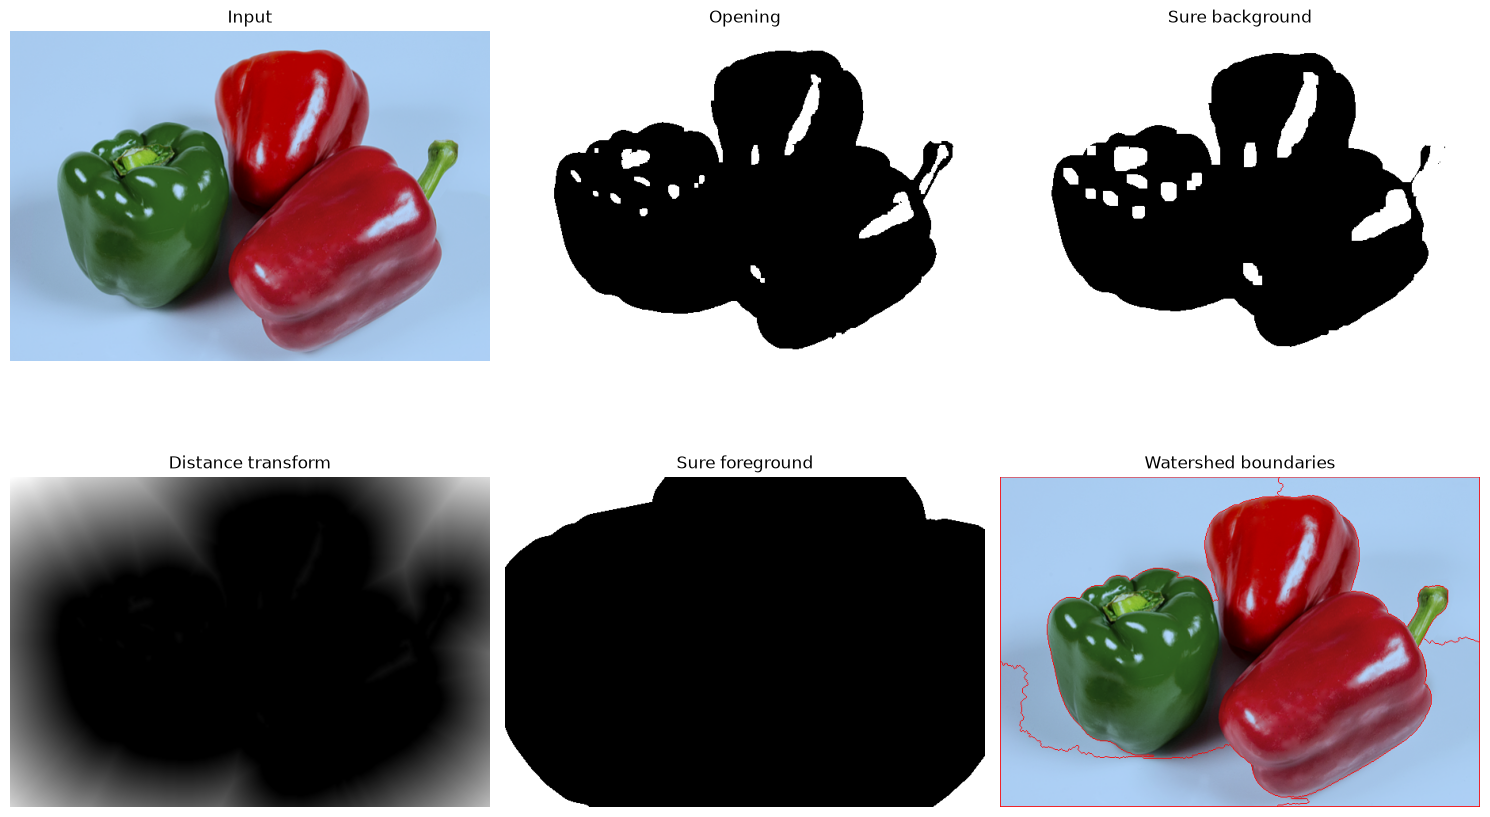

In [24]:
watershed_input = peppers_rgb.copy()

peppers_gray = cv2.cvtColor(
    peppers_rgb,
    cv2.COLOR_RGB2GRAY
)

_, peppers_binary = cv2.threshold(
    peppers_gray,
    0,
    255,
    cv2.THRESH_BINARY
    + cv2.THRESH_OTSU
)

ws_kernel = np.ones(
    (3, 3),
    np.uint8
)

opening = cv2.morphologyEx(
    peppers_binary,
    cv2.MORPH_OPEN,
    ws_kernel,
    iterations=2
)

sure_bg = cv2.dilate(
    opening,
    ws_kernel,
    iterations=3
)

dist_transform = cv2.distanceTransform(
    opening,
    cv2.DIST_L2,
    5
)

_, sure_fg = cv2.threshold(
    dist_transform,
    0.5 * dist_transform.max(),
    255,
    0
)

sure_fg = np.uint8(
    sure_fg
)

unknown = cv2.subtract(
    sure_bg,
    sure_fg
)

num_markers, markers = cv2.connectedComponents(
    sure_fg
)

markers = markers + 1
markers[unknown == 255] = 0

markers_ws = cv2.watershed(
    cv2.cvtColor(
        watershed_input,
        cv2.COLOR_RGB2BGR
    ),
    markers.copy()
)

watershed_view = watershed_input.copy()
watershed_view[
    markers_ws == -1
] = [255, 0, 0]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 10)
)

show_rgb(
    axes[0, 0],
    peppers_rgb,
    "Input"
)

show_gray(
    axes[0, 1],
    opening,
    "Opening"
)

show_gray(
    axes[0, 2],
    sure_bg,
    "Sure background"
)

show_gray(
    axes[1, 0],
    dist_transform,
    "Distance transform"
)

show_gray(
    axes[1, 1],
    sure_fg,
    "Sure foreground"
)

show_rgb(
    axes[1, 2],
    watershed_view,
    "Watershed boundaries"
)

fig.tight_layout()
save_figure(
    fig,
    "20_watershed.png"
)
plt.show()

### Watershed Failure Modes

**Over-segmentation**  
Too many regions are created.

Typical causes:

- noisy image;
- too many markers;
- weak smoothing.

**Under-segmentation**  
Different objects remain merged.

Typical causes:

- markers not separated;
- poor foreground mask;
- insufficient distance-transform separation.

Marker quality is often more important than the watershed call itself.

## 23. Ground Truth and Segmentation Metrics

To evaluate segmentation properly, compare a predicted mask with a ground-truth mask.

Let:

- TP = true positive pixels;
- TN = true negative pixels;
- FP = false positive pixels;
- FN = false negative pixels.

### Pixel Accuracy

$$
\mathrm{Accuracy}
=
\frac{TP+TN}
{TP+TN+FP+FN}
$$

Accuracy can be misleading when background dominates the image.

### Precision

$$
\mathrm{Precision}
=
\frac{TP}
{TP+FP}
$$

Of the pixels predicted as foreground, how many were actually foreground?

### Recall

$$
\mathrm{Recall}
=
\frac{TP}
{TP+FN}
$$

Of the true foreground pixels, how many did we recover?

### Intersection over Union (IoU)

$$
\mathrm{IoU}
=
\frac{|A\cap B|}
{|A\cup B|}
$$

Also called the Jaccard index.

### Dice Score

$$
\mathrm{Dice}
=
\frac{2|A\cap B|}
{|A|+|B|}
$$

Dice and IoU are widely used in segmentation because they focus directly on region overlap.

In [25]:
def segmentation_metrics(
    ground_truth,
    prediction
):
    gt = np.asarray(
        ground_truth
    ).astype(bool)

    pred = np.asarray(
        prediction
    ).astype(bool)

    tp = np.logical_and(
        gt,
        pred
    ).sum()

    tn = np.logical_and(
        ~gt,
        ~pred
    ).sum()

    fp = np.logical_and(
        ~gt,
        pred
    ).sum()

    fn = np.logical_and(
        gt,
        ~pred
    ).sum()

    epsilon = 1e-12

    accuracy = (
        (tp + tn)
        / (tp + tn + fp + fn + epsilon)
    )

    precision = (
        tp
        / (tp + fp + epsilon)
    )

    recall = (
        tp
        / (tp + fn + epsilon)
    )

    iou = (
        tp
        / (tp + fp + fn + epsilon)
    )

    dice = (
        2 * tp
        / (2 * tp + fp + fn + epsilon)
    )

    return {
        "TP": int(tp),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "IoU": iou,
        "Dice": dice,
    }

### Demonstration with a synthetic ground truth

The lab does not include an official ground-truth mask for `hand.png`.

So the following example only demonstrates metric computation.

It must **not** be interpreted as a real benchmark of the segmentation.

In [26]:
demo_gt = clean_components.copy()

demo_prediction = cv2.erode(
    to_uint8_mask(
        clean_components
    ),
    np.ones(
        (7, 7),
        np.uint8
    ),
    iterations=1
) > 0

demo_metrics = segmentation_metrics(
    demo_gt,
    demo_prediction
)

for key, value in demo_metrics.items():
    if isinstance(value, float):
        print(
            f"{key:10s}: {value:.4f}"
        )
    else:
        print(
            f"{key:10s}: {value}"
        )

TP        : 274588
TN        : 28220
FP        : 0
FN        : 4392
Accuracy  : 0.9857
Precision : 1.0000
Recall    : 0.9843
IoU       : 0.9843
Dice      : 0.9921


## 24. Dice vs IoU Relationship

For the same prediction:

$$
\mathrm{Dice}
=
\frac{2\mathrm{IoU}}
{1+\mathrm{IoU}}
$$

and:

$$
\mathrm{IoU}
=
\frac{\mathrm{Dice}}
{2-\mathrm{Dice}}
$$

Dice is numerically larger than IoU for the same non-perfect segmentation, but both measure overlap.

## 25. Under-Segmentation vs Over-Segmentation

### Under-segmentation

Different real objects are merged into one segment.

### Over-segmentation

One real object is split into too many segments.

These concepts are different from false positives and false negatives.

They describe how regions are partitioned.

## 26. End-to-End Binary Segmentation Pipeline

A practical classical pipeline often looks like:

```text
input image
    ↓
grayscale conversion
    ↓
noise reduction
    ↓
thresholding
    ↓
morphological cleanup
    ↓
hole filling
    ↓
connected components
    ↓
remove small regions
    ↓
contours / measurements
    ↓
final mask + overlay
```

We now package this into a reusable function.

In [27]:
def segment_dark_object(
    image_gray,
    blur_kernel=(5, 5),
    minimum_area=500
):
    blurred = cv2.GaussianBlur(
        image_gray,
        blur_kernel,
        0
    )

    threshold_value, binary = cv2.threshold(
        blurred,
        0,
        255,
        cv2.THRESH_BINARY_INV
        + cv2.THRESH_OTSU
    )

    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (5, 5)
    )

    cleaned = cv2.morphologyEx(
        binary,
        cv2.MORPH_OPEN,
        kernel
    )

    cleaned = cv2.morphologyEx(
        cleaned,
        cv2.MORPH_CLOSE,
        kernel
    )

    filled = ndimage.binary_fill_holes(
        cleaned > 0
    )

    num_labels, labels, stats, _ = (
        cv2.connectedComponentsWithStats(
            to_uint8_mask(filled),
            connectivity=8
        )
    )

    final_mask = np.zeros_like(
        filled,
        dtype=bool
    )

    for label_id in range(
        1,
        num_labels
    ):
        area = stats[
            label_id,
            cv2.CC_STAT_AREA
        ]

        if area >= minimum_area:
            final_mask |= (
                labels == label_id
            )

    return {
        "threshold": threshold_value,
        "blurred": blurred,
        "binary": binary > 0,
        "cleaned": cleaned > 0,
        "filled": filled,
        "mask": final_mask,
    }

Saved: 21_complete_pipeline.png


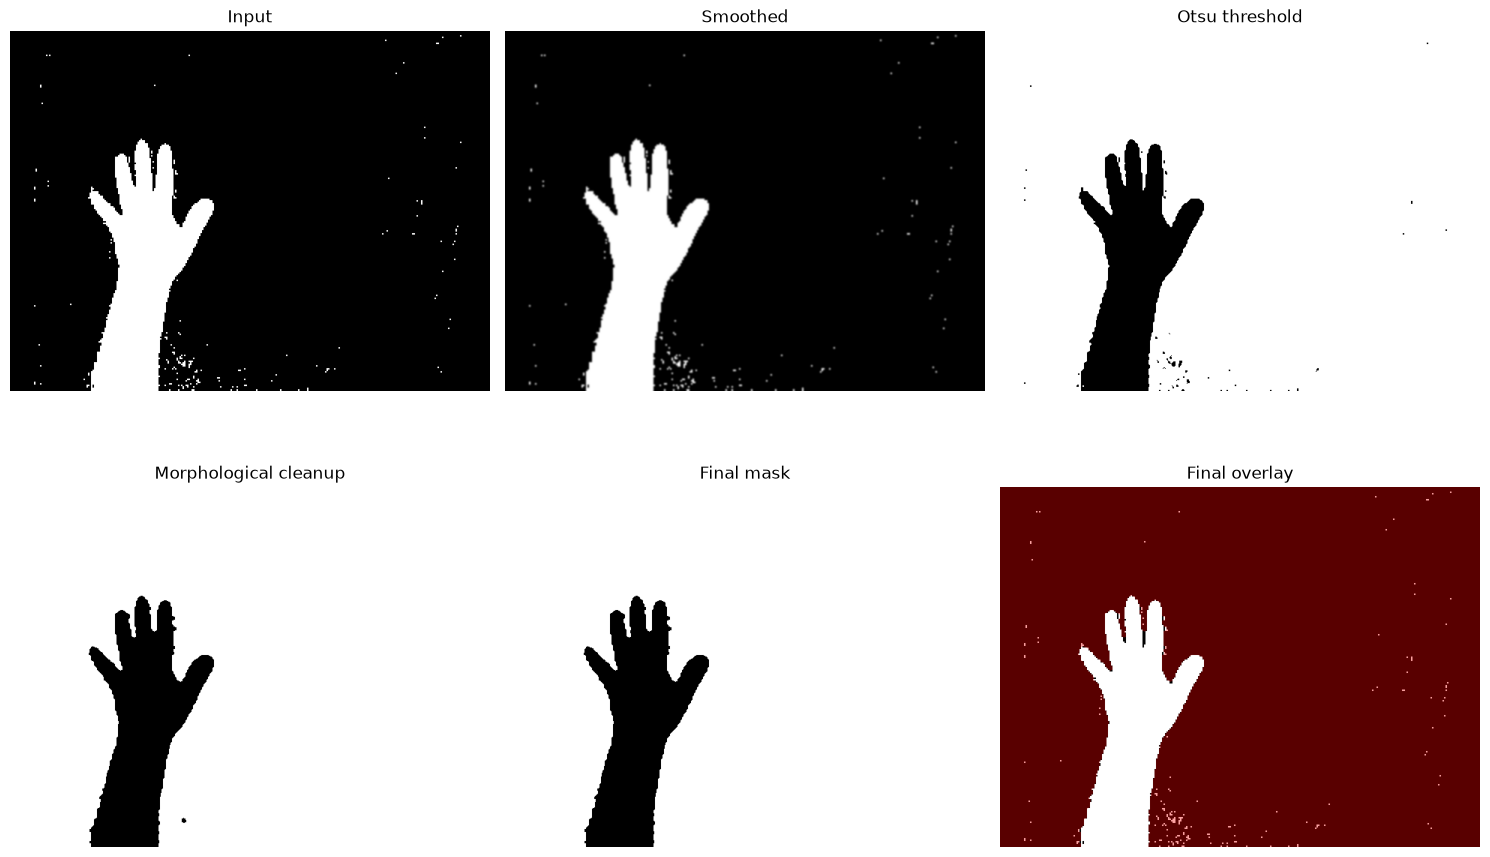

Pipeline Otsu threshold: 121.0


In [28]:
hand_result = segment_dark_object(
    hand,
    minimum_area=500
)

final_hand_mask = hand_result[
    "mask"
]

final_overlay = overlay_mask(
    np.stack(
        [hand] * 3,
        axis=-1
    ),
    final_hand_mask
)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 10)
)

show_gray(
    axes[0, 0],
    hand,
    "Input"
)

show_gray(
    axes[0, 1],
    hand_result["blurred"],
    "Smoothed"
)

show_gray(
    axes[0, 2],
    hand_result["binary"],
    "Otsu threshold"
)

show_gray(
    axes[1, 0],
    hand_result["cleaned"],
    "Morphological cleanup"
)

show_gray(
    axes[1, 1],
    final_hand_mask,
    "Final mask"
)

show_rgb(
    axes[1, 2],
    final_overlay,
    "Final overlay"
)

fig.tight_layout()
save_figure(
    fig,
    "21_complete_pipeline.png"
)
plt.show()

print(
    "Pipeline Otsu threshold:",
    hand_result["threshold"]
)

## 27. How to Choose a Segmentation Strategy

Ask these questions:

### Is intensity separation strong?

Use:

- global threshold;
- Otsu.

### Is illumination uneven?

Try:

- adaptive thresholding;
- illumination correction first.

### Is color the main distinction?

Use:

- HSV;
- Lab;
- color ranges/clustering.

### Are objects touching?

Use:

- distance transform;
- markers;
- watershed.

### Is the mask noisy?

Use:

- opening;
- component-area filtering.

### Are there holes/gaps?

Use:

- closing;
- hole filling.

### Is the task boundary-driven?

Use:

- Canny or other edge detector;
- boundary linking;
- contour processing.

## 31. Final Concept Map

```text
INPUT IMAGE
    │
    ├── intensity based ───────► threshold / Otsu / adaptive
    │
    ├── color based ───────────► HSV / Lab ranges
    │
    └── boundary based ────────► edges / contours
                                │
                                ▼
                         INITIAL MASK
                                │
                                ▼
                       MORPHOLOGICAL CLEANUP
                   erosion / dilation / open / close
                                │
                                ▼
                       CONNECTED COMPONENTS
                                │
                                ▼
                         REGION MEASUREMENTS
                                │
             ┌──────────────────┴──────────────────┐
             │                                     │
      touching objects                        final mask
             │                                     │
       distance transform                           ▼
             │                              Dice / IoU / etc.
         watershed
```

## Discussion

Classical segmentation is built from simple operations, but strong results come from combining them correctly.

The most important lesson is:

> segmentation quality depends on the entire pipeline, not only the final threshold or algorithm.

A useful segmentation engineer should understand:

- image formation;
- preprocessing;
- intensity/color distributions;
- morphology;
- connectivity;
- geometry;
- evaluation metrics.

These concepts remain useful even when segmentation is later performed with deep neural networks.

## Conclusion

You now have the complete classical segmentation chain:

1. segmentation assigns labels to pixels;
2. thresholding creates initial binary masks;
3. Otsu selects a global threshold automatically;
4. adaptive thresholding handles uneven illumination;
5. morphology cleans and reshapes masks;
6. connected components identify separate regions;
7. contours represent boundaries;
8. region properties quantify shape;
9. color spaces enable color-based segmentation;
10. distance transforms support object separation;
11. watershed can separate touching regions;
12. Dice and IoU quantify mask overlap;
13. complete segmentation requires preprocessing, segmentation, cleanup, analysis, and evaluation.

This prepares the way for the final image-processing project and for later computer-vision segmentation methods.